# QuickBite Express Crisis Analysis

## Objective
Analyze the June 2025 crisis impact and identify drivers of revenue decline using revenue decomposition and cohort retention.

## Step 1: Load Aggregated Monthly Summary
This query retrieves weekly revenue, active customers, order frequency, and AOV.

In [3]:
import pyodbc
import pandas ad pd

conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=RABDI\\SQLEXPRESS01;"
    "Database=quitebit;"
    "Trusted_Connection=yes;"
)

print("Connection successful")

Connection successful


In [4]:
query_1 = """
with weekly_orders as (
    select
        d.phase,
        cast(dateadd(week, datediff(week, 0, d.[date]), 0) as date) as week_start_date,
        count(distinct o.order_id) as weekly_order,
        count(distinct o.customer_id) as weekly_active_customer,
        count(distinct case when is_cancelled = 'Y' then o.order_id end) as weekly_cancel_order,
        count(distinct o.restaurant_id) as weekly_active_restaurant
    from fact_orders as o
    inner join dim_date as d
        on d.[date] = cast(o.order_timestamp as date)
    group by dateadd(week, datediff(week, 0, d.[date]), 0), d.phase
),
weekly_rating as (
    select
        cast(dateadd(week, datediff(week, 0, d.[date]), 0) as date) as week_start_date,
        avg(cast(r.rating as float)) as avg_weekly_rating
    from fact_ratings as r
    inner join fact_orders as o
        on o.order_id = r.order_id
    inner join dim_date as d
        on d.[date] = cast(o.order_timestamp as date)
    group by dateadd(week, datediff(week, 0, d.[date]), 0)
), 
weekly_deliverytime as (
    select
        cast(dateadd(week, datediff(week,0,  d.[date]), 0) as date) as week_start_date,
        avg(cast(dp.actual_delivery_time_mins as float)) as avg_weekly_actual_time,
        avg(cast(dp.expected_delivery_time_mins as float)) as avg_weekly_expected_time
        from fact_delivery_performance as dp
        inner join fact_orders as o
            on o.order_id = dp.order_id
        inner join dim_date as d
            on d.[date] = cast(o.order_timestamp as date)
        group by dateadd(week, datediff(week,0,d.[date]), 0)
)
select 
    wo.*,
    cast(wo.weekly_order as float) / nullif(wo.weekly_active_customer, 0) as weekly_frequency,
    cast(wo.weekly_cancel_order as float) / nullif(wo.weekly_order, 0) as cancellation_rate,
    wr.avg_weekly_rating,
    wd.avg_weekly_actual_time,
    wd.avg_weekly_expected_time,
    (wd.avg_weekly_actual_time - wd.avg_weekly_expected_time) as avg_weekly_delay_min
from weekly_orders as wo
left join weekly_rating as wr
    on wo.week_start_date = wr.week_start_date
left join weekly_deliverytime as wd
    on wo.week_start_date = wd.week_start_date
order by wo.week_start_date;
"""

weekly_df = pd.read_sql(query_1, conn)




C:\Users\sahil\AppData\Local\Temp\ipykernel_30188\3540845462.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  weekly_df = pd.read_sql(query_1, conn)


## Step 3: Cohort Retention Analysis
Measure May cohort continuation into June and July.

In [5]:
query_2 = """
with may_customers as (
    select distinct o.customer_id
    from fact_orders o
    where o.order_timestamp >= '2025-05-01'
      and o.order_timestamp <  '2025-06-01'
),
june_experience as (
    select
        o.customer_id,
        max(case 
              when (cast(dp.actual_delivery_time_mins as float) 
                    - cast(dp.expected_delivery_time_mins as float)) > 15 
              then 1 else 0 end) as high_delay_flag,
        max(case when o.is_cancelled = 'y' then 1 else 0 end) as cancelled_flag
    from fact_orders o
    left join fact_delivery_performance dp
        on o.order_id = dp.order_id
    where o.order_timestamp >= '2025-06-01'
      and o.order_timestamp <  '2025-07-01'
    group by o.customer_id
),
july_retention as (
    select distinct o.customer_id, 1 as retained_flag
    from fact_orders o
    where o.order_timestamp >= '2025-07-01'
      and o.order_timestamp <  '2025-08-01'
),
customer_flags as (
    select
        'may_2025' as cohort_name, -- Added cohort identifier
        m.customer_id,
        isnull(j.high_delay_flag, 0) as high_delay_flag,
        isnull(j.cancelled_flag, 0) as cancelled_flag,
        isnull(r.retained_flag, 0) as retained_flag
    from may_customers m
    left join june_experience j
        on m.customer_id = j.customer_id
    left join july_retention r
        on m.customer_id = r.customer_id
)
select
    cohort_name, -- Grouping by cohort for easier merging later
    high_delay_flag,
    cancelled_flag,
    count(*) as total_customers,
    sum(retained_flag) as retained_customers, -- Essential for proportion tests
    avg(cast(retained_flag as float)) as retention_rate
from customer_flags
group by cohort_name, high_delay_flag, cancelled_flag
order by high_delay_flag desc, cancelled_flag desc;
"""

retention_df = pd.read_sql(query_2, conn)

C:\Users\sahil\AppData\Local\Temp\ipykernel_30188\1513612691.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  retention_df = pd.read_sql(query_2, conn)


In [6]:
query_3 = """
with may_customers as (
    select
        o.customer_id,
        count(*) as may_order_count
    from fact_orders o
    where o.order_timestamp >= '2025-05-01'
      and o.order_timestamp <  '2025-06-01'
      and o.is_cancelled = 'n'
    group by o.customer_id
),

june_experience as (
    select
        o.customer_id,

        -- june order activity flags
        max(case when o.is_cancelled = 'n' then 1 else 0 end) as june_non_cancel_order_flag,
        max(case when o.is_cancelled = 'y' then 1 else 0 end) as june_cancelled_flag,

        -- ops experience flags
        max(case
              when (cast(dp.actual_delivery_time_mins as float)
                    - cast(dp.expected_delivery_time_mins as float)) > 10
              then 1 else 0 end) as delay_diff_flag,
        max(case
              when cast(dp.actual_delivery_time_mins as float) > 45
              then 1 else 0 end) as long_delivery_flag,

        -- trust/quality signal: low rating (<=2) on a non-cancelled order
        max(case
              when o.is_cancelled = 'n' and r.rating <= 2
              then 1 else 0 end) as low_rating_flag

    from fact_orders o
    left join fact_delivery_performance dp
        on o.order_id = dp.order_id
    left join fact_ratings r
        on o.order_id = r.order_id
    where o.order_timestamp >= '2025-06-01'
      and o.order_timestamp <  '2025-07-01'
    group by o.customer_id
),

july_retention as (
    select distinct
        o.customer_id,
        1 as retained_flag
    from fact_orders o
    where o.order_timestamp >= '2025-07-01'
      and o.order_timestamp <  '2025-08-01'
      and o.is_cancelled = 'n'
),

customer_flags as (
    select
        m.customer_id,
        m.may_order_count,
        isnull(j.low_rating_flag, 0) as low_rating_flag,
        isnull(r.retained_flag, 0) as retained_flag
    from may_customers m
    left join june_experience j
        on m.customer_id = j.customer_id
    left join july_retention r
        on m.customer_id = r.customer_id
)

select
    low_rating_flag,
    count(*) as customers,
    sum(retained_flag) as retained_count,
    avg(cast(retained_flag as float)) as retention_rate,
    avg(cast(may_order_count as float)) as avg_may_order_count
from customer_flags
group by low_rating_flag
order by low_rating_flag desc;
"""

retention_rating_df = pd.read_sql(query_3, conn)

C:\Users\sahil\AppData\Local\Temp\ipykernel_30188\2080814070.py:79: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  retention_rating_df = pd.read_sql(query_3, conn)


In [7]:
query_4 = """
with city_phase as (
    select
        r.city,
        d.phase,
        count(*) as orders,
        cast(sum(coalesce(try_cast(o.total_amount as decimal(18,2)), 0)) as decimal(18,2)) as revenue,
        count(distinct o.customer_id) as active_customers,
        count(distinct o.restaurant_id) as active_restaurants,

        count(distinct case when r.is_active = 1 then o.restaurant_id end) as active_partner_restaurants,

        avg(case when r.is_active = 1 then
            case 
                when r.avg_prep_time_min = '0-15'  then 7.5
                when r.avg_prep_time_min = '16-25' then 20.5
                when r.avg_prep_time_min = '26-40' then 33.0
                when r.avg_prep_time_min = '>40'   then 45.0
                else try_cast(r.avg_prep_time_min as float)
            end
        end) as avg_prep_time_active_restaurants

    from fact_orders o
    join dim_date d
      on d.[date] = cast(o.order_timestamp as date)
    join dim_restaurant r
      on r.restaurant_id = o.restaurant_id
    where o.is_cancelled = 'n'
      and d.phase in ('pre', 'crisis', 'post')
    group by r.city, d.phase
),
phase_totals as (
    select
        phase,
        sum(revenue) as total_phase_revenue
    from city_phase
    group by phase
)
select
    cp.city,
    cp.phase,
    cp.orders,
    cp.revenue,
    cp.active_customers,
    cp.active_restaurants,
    cp.active_partner_restaurants,
    cp.avg_prep_time_active_restaurants,

    cast(cp.orders * 1.0 / nullif(cp.active_customers, 0) as decimal(10,4)) as frequency,
    cast(cp.revenue * 1.0 / nullif(cp.orders, 0) as decimal(10,2)) as aov,
    cast(cp.revenue * 1.0 / nullif(pt.total_phase_revenue, 0) as decimal(10,6)) as revenue_share_in_phase
from city_phase cp
join phase_totals pt
  on cp.phase = pt.phase
order by
    cp.city,
case cp.phase when 'pre' then 1 when 'crisis' then 2 else 3 end;
"""

city_revenue_df = pd.read_sql(query_4, conn)

C:\Users\sahil\AppData\Local\Temp\ipykernel_30188\1296019590.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city_revenue_df = pd.read_sql(query_4, conn)


In [58]:
weekly_df.head()

,phase,week_start_date,weekly_order,weekly_active_customer,weekly_cancel_order,weekly_active_restaurant,weekly_frequency,cancellation_rate,avg_weekly_rating,avg_weekly_actual_time,avg_weekly_expected_time,avg_weekly_delay_min
0,pre,2024-12-30,3033,3001,197,2812,1.010663,0.064952,4.580095,39.320804,37.438839,1.881965
1,pre,2025-01-06,5313,5237,312,4676,1.014512,0.058724,4.573759,39.456428,37.469603,1.986825
2,pre,2025-01-13,5309,5245,331,4695,1.012202,0.062347,4.576273,39.747222,37.572801,2.174421
3,pre,2025-01-20,5301,5228,347,4618,1.013963,0.065459,4.573526,39.636861,37.538955,2.097906
4,pre,2025-01-27,5369,5280,318,4699,1.016856,0.059229,4.555215,39.619296,37.457627,2.161669


In [48]:
retention_df.head()

,cohort_name,high_delay_flag,cancelled_flag,total_customers,retained_customers,retention_rate
0,may_2025,1,1,58,6,0.103448
1,may_2025,1,0,470,17,0.036170
2,may_2025,0,1,39,2,0.051282
3,may_2025,0,0,20783,944,0.045422


In [49]:
retention_rating_df.head()

,low_rating_flag,customers,retained_count,retention_rate,avg_may_order_count
0,1,73,3,0.041096,1.109589
1,0,20065,800,0.039870,1.053576


In [56]:
city_revenue_df.head()

,city,phase,orders,revenue,active_customers,active_restaurants,active_partner_restaurants,avg_prep_time_active_restaurants,frequency,aov,revenue_share_in_phase
0,Ahmedabad,pre,8786,3106440.75,8604,1619,1456,28.007860,1.0212,353.57,0.082572
1,Ahmedabad,crisis,655,230731.18,654,541,483,27.331498,1.0015,352.26,0.079897
2,Ahmedabad,post,1881,665169.57,1869,1126,1015,28.027502,1.0064,353.63,0.082606
3,Bengaluru,pre,26477,9287063.16,24797,4941,4439,27.980966,1.0678,350.76,0.246859
4,Bengaluru,crisis,1992,699938.01,1985,1649,1472,27.981481,1.0035,351.37,0.242372


In [55]:
city_revenue_df.columns

Index(['city', 'phase', 'orders', 'revenue', 'active_customers',
       'active_restaurants', 'active_partner_restaurants',
       'avg_prep_time_active_restaurants', 'frequency', 'aov',
       'revenue_share_in_phase'],
      dtype='object')

## Step 4: Visualizing Demand Shock
Index metrics to Pre-Crisis baseline (Pre = 100).

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Preparation ---
weekly = weekly_df.copy()
weekly["week_start_date"] = pd.to_datetime(weekly["week_start_date"])
weekly = weekly.sort_values("week_start_date")

# --- Step 1: Calculate Indices ---
pre_mask = weekly["phase"] == "pre"
base_metrics = {
    "orders": weekly.loc[pre_mask, "weekly_order"].mean(),
    "customers": weekly.loc[pre_mask, "weekly_active_customer"].mean(),
    "delay": weekly.loc[pre_mask, "avg_weekly_delay_min"].mean(),
    "rating": weekly.loc[pre_mask, "avg_weekly_rating"].mean(),
    "cancel": weekly.loc[pre_mask, "cancellation_rate"].mean()
}

weekly["orders_index"] = (weekly["weekly_order"] / base_metrics["orders"]) * 100
weekly["customers_index"] = (weekly["weekly_active_customer"] / base_metrics["customers"]) * 100
weekly["delay_index"] = (weekly["avg_weekly_delay_min"] / base_metrics["delay"]) * 100
weekly["rating_index"] = (weekly["avg_weekly_rating"] / base_metrics["rating"]) * 100
weekly["cancel_index"] = (weekly["cancellation_rate"] / base_metrics["cancel"]) * 100

# --- Modular Function with Phase Highlighting ---
def plot_weekly_metric(df, column, title, ylabel, is_index=True):
    plt.figure(figsize=(12, 5))
    plt.plot(df["week_start_date"], df[column], marker='o', linestyle='-', linewidth=2, color='#2c3e50')
    
    # Baseline for Index plots
    if is_index:
        plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Pre-Crisis Baseline')
    
    # Phase Background Shading
    # We find the start/end dates for each phase
    for phase, color in zip(['pre', 'crisis', 'post'], ['#ecf0f1', '#f9ebea', '#e8f8f5']):
        phase_data = df[df['phase'] == phase]
        if not phase_data.empty:
            plt.axvspan(phase_data['week_start_date'].min(), 
                        phase_data['week_start_date'].max(), 
                        color=color, alpha=0.5, label=f'Phase: {phase.upper()}')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel(ylabel)
    plt.xlabel("Week Start Date")
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    
    # Format X-Axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# --- Execution: One by One ---


## Metric Definitions

- Active Customer: Customer placing ≥1 order in a given month
- Order Frequency: Total Orders / Active Customers
- AOV: Total Revenue / Total Orders
- Retention: % of May cohort ordering in subsequent months

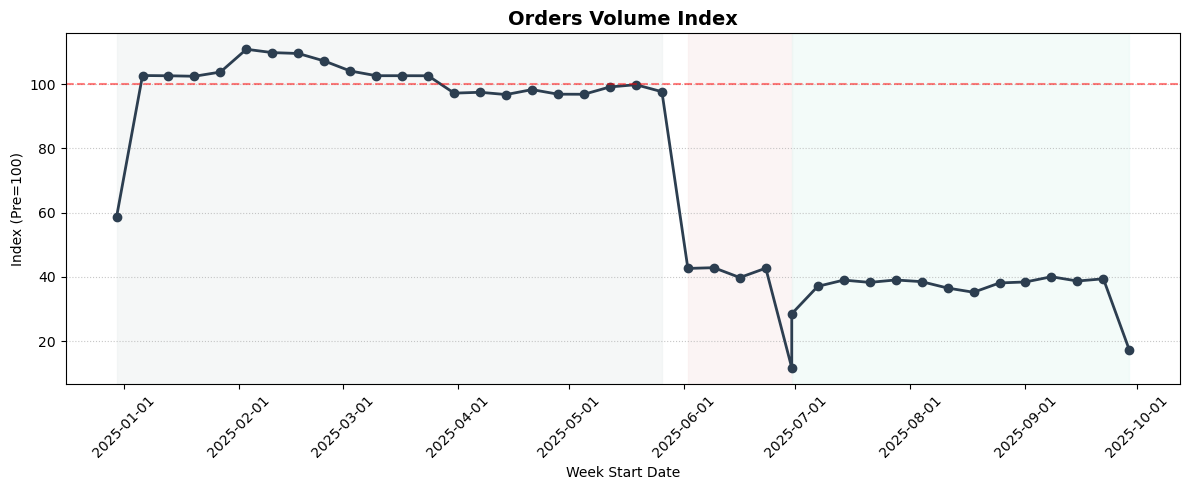

In [63]:
# 1. Orders Index
plot_weekly_metric(weekly, "orders_index", "Orders Volume Index", "Index (Pre=100)")

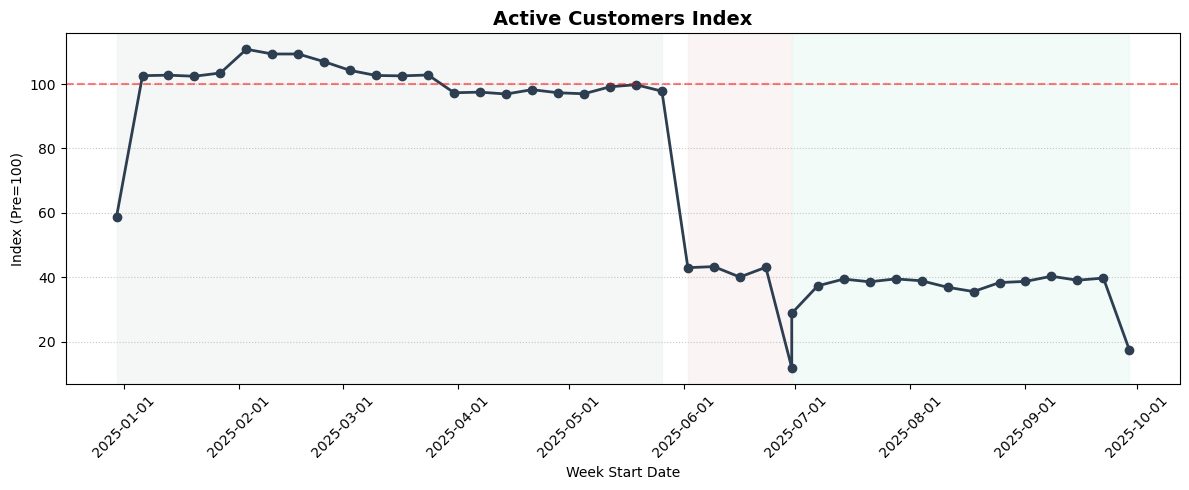

In [64]:

# 2. Customers Index
plot_weekly_metric(weekly, "customers_index", "Active Customers Index", "Index (Pre=100)")

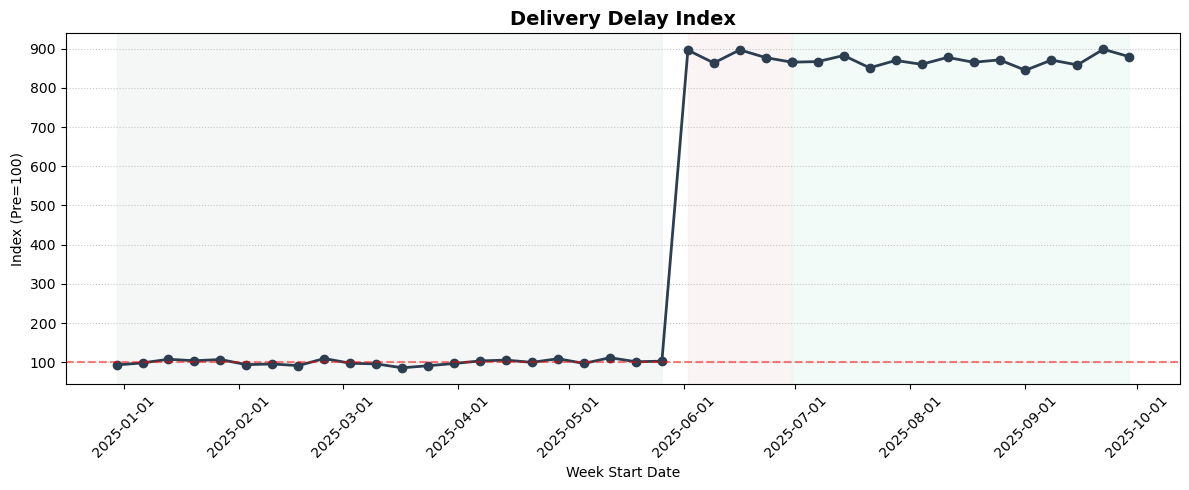

In [65]:
# 3. Delivery Delay Index
plot_weekly_metric(weekly, "delay_index", "Delivery Delay Index", "Index (Pre=100)")

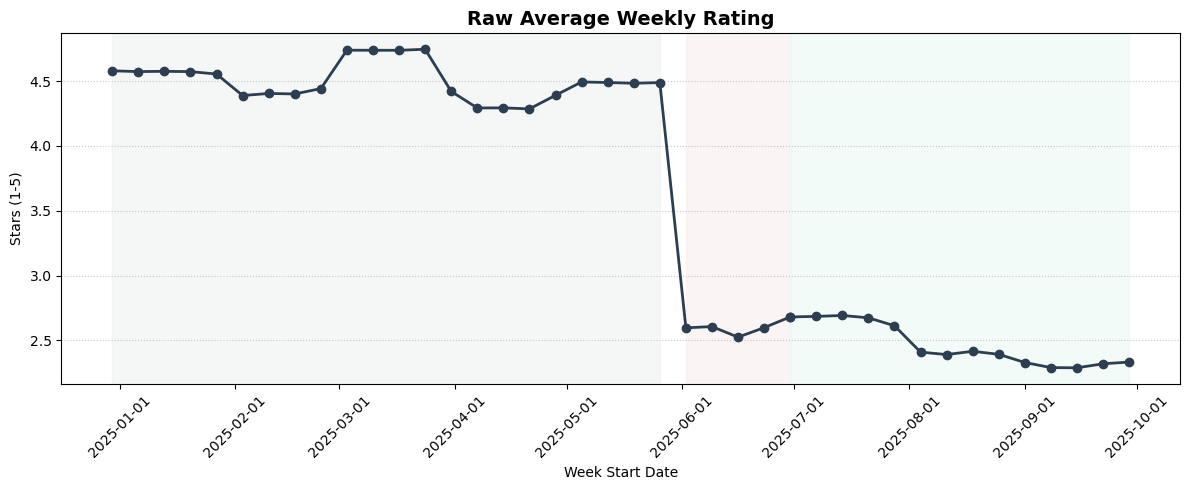

In [66]:
# 4. Raw Rating
plot_weekly_metric(weekly, "avg_weekly_rating", "Raw Average Weekly Rating", "Stars (1-5)", is_index=False)

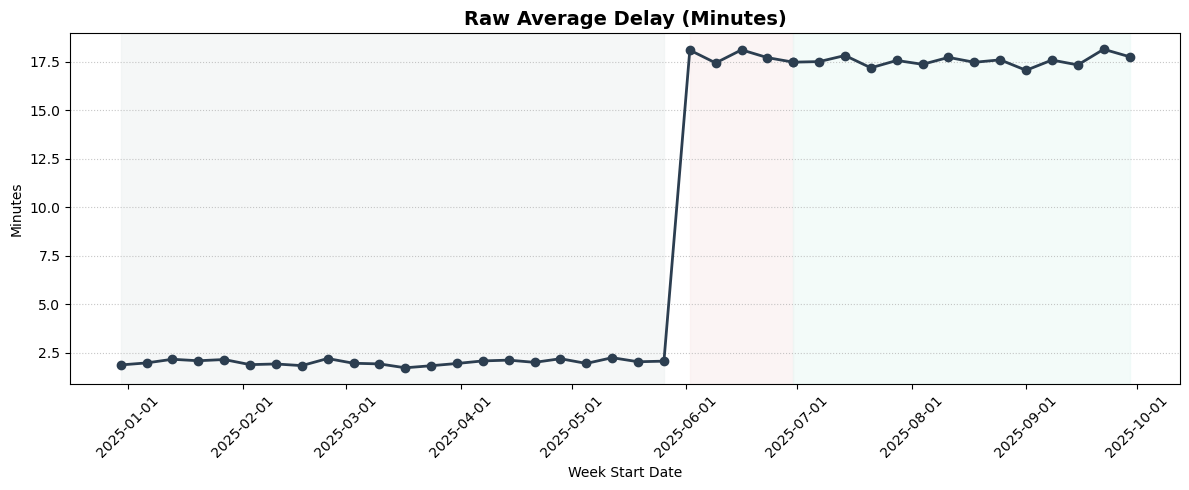

In [67]:
# 5. Raw Delay
plot_weekly_metric(weekly, "avg_weekly_delay_min", "Raw Average Delay (Minutes)", "Minutes", is_index=False)

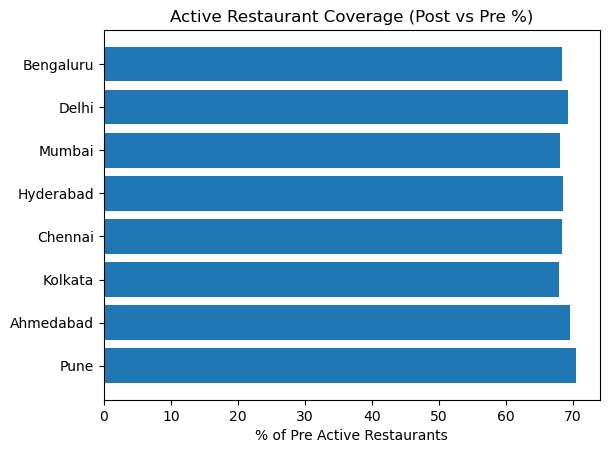

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

city = city_revenue_df.copy()

pivot_rest = city.pivot(index='city', columns='phase', values='active_restaurants')

pivot_rest['post_vs_pre_pct'] = pivot_rest['post'] / pivot_rest['pre'] * 100

pivot_rest = pivot_rest.sort_values('pre', ascending=False)

plt.figure()
plt.barh(pivot_rest.index, pivot_rest['post_vs_pre_pct'])
plt.title("Active Restaurant Coverage (Post vs Pre %)")
plt.xlabel("% of Pre Active Restaurants")
plt.gca().invert_yaxis()
plt.show()

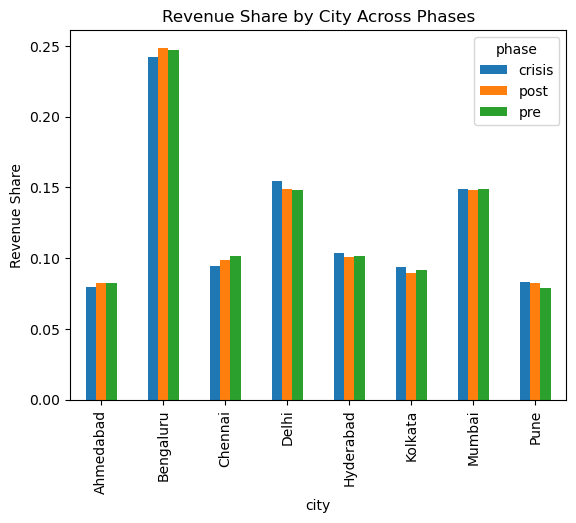

In [70]:
pivot_share = city.pivot(index='city', columns='phase', values='revenue_share_in_phase')

pivot_share.plot(kind='bar')
plt.title("Revenue Share by City Across Phases")
plt.ylabel("Revenue Share")
plt.show()

# Covert the query to CSV file

In [71]:
weekly_df.to_csv("weekly_df.csv", index=False)
retention_df.to_csv("retention_df.csv", index=False)
retention_rating_df.to_csv("retention_rating_df.csv", index=False)
city_revenue_df.to_csv("city_revenue_df.csv", index=False)

## Key Insights

- Revenue decline driven by customer contraction (~90% drop)
- AOV and frequency remained stable
- Demand shock was systemic rather than basket-driven
- Recovery incomplete in customer base restoration